In [1]:
!pip install -q mlflow
!pip install -q --no-cache-dir --force-reinstall --no-deps git+https://github.com/RayenSansa03/aeroguard.git@main

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
print("--- metier.py sur GitHub (main) ---")
!curl -s https://raw.githubusercontent.com/RayenSansa03/aeroguard/main/src/aeroguard/metier.py | grep -n "^def "
print("\n--- metier.py installé dans Colab ---")
!grep -n "^def " $(python -c "import aeroguard, os; print(os.path.dirname(aeroguard.__file__))")/metier.py

--- metier.py sur GitHub (main) ---
7:def alertes_confirmees(alertes, k=1):
15:def avance_alerte(alertes, y, rul, k=1):
24:def fausses_alarmes(alertes, y, k=1):
30:def bilan_flotte(table, col_moteur="unit", col_ordre="cycle", col_rul="RUL", k=1):
47:def resume_flotte(bilan):
59:def diagnostic_par_moteur(moteurs, predictions):
65:def evaluer_alerte(
84:def evaluer_alerte_score(
101:def bilan_par_groupe(

--- metier.py installé dans Colab ---
7:def alertes_confirmees(alertes, k=1):
15:def avance_alerte(alertes, y, rul, k=1):
24:def fausses_alarmes(alertes, y, k=1):
30:def bilan_flotte(table, col_moteur="unit", col_ordre="cycle", col_rul="RUL", k=1):
47:def resume_flotte(bilan):
59:def diagnostic_par_moteur(moteurs, predictions):
65:def evaluer_alerte(
84:def evaluer_alerte_score(
101:def bilan_par_groupe(


In [3]:
from google.colab import drive
drive.mount("/content/drive")

import math
import os
import shutil
import time

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd

from aeroguard.donnees_ml import preparer_xy

DOSSIER = "/content/drive/MyDrive/aeroguard"
DOSSIER_MLFLOW_LOCAL = "/content/mlflow"
DOSSIER_MLFLOW_DRIVE = f"{DOSSIER}/mlflow"
if os.path.exists(DOSSIER_MLFLOW_DRIVE) and not os.path.exists(DOSSIER_MLFLOW_LOCAL):
    shutil.copytree(DOSSIER_MLFLOW_DRIVE, DOSSIER_MLFLOW_LOCAL)
if os.path.exists(f"{DOSSIER}/mlruns") and not os.path.exists("/content/mlruns"):
    shutil.copytree(f"{DOSSIER}/mlruns", "/content/mlruns")
os.makedirs(DOSSIER_MLFLOW_LOCAL, exist_ok=True)
mlflow.set_tracking_uri(f"sqlite:///{DOSSIER_MLFLOW_LOCAL}/mlflow.db")

vols = pd.read_parquet(f"{DOSSIER}/data/processed/vols_ncmapss.parquet")
X_train, y_train = preparer_xy(vols, "train")
X_val, y_val = preparer_xy(vols, "val")

# Tous les vols HORS TEST (le test reste fermé jusqu'à la 5.6)
X_hors_test = pd.concat([X_train, X_val])
y_np = pd.concat([y_train, y_val]).to_numpy()
infos_hors_test = vols.loc[X_hors_test.index, ["moteur", "cycle", "RUL"]]
famille = vols.loc[X_hors_test.index, "famille"].astype(str).to_numpy()
groupe = vols.loc[X_hors_test.index, "groupe"].to_numpy()
assert not X_hors_test.isna().any().any(), "Pas de valeur manquante attendue hors test."

X_np = X_hors_test.to_numpy(dtype="float64")
est_train = groupe == "train"
est_val = groupe == "val"
sains = y_np == 0

repartition = (vols[vols["groupe"].isin(["train", "val"])]
               .groupby(["famille", "groupe"])["moteur"].nunique().unstack(fill_value=0))
repartition["total"] = repartition.sum(axis=1)
print(f"{len(X_hors_test)} vols hors test, {infos_hors_test['moteur'].nunique()} moteurs")
repartition

Mounted at /content/drive
4535 vols hors test, 60 moteurs


groupe,train,val,total
famille,,,
HPC,5,1,6
HPT,8,1,9
HPT+LPT,6,3,9
LPC+HPC,5,1,6
LPT,8,1,9
fan,5,1,6
mixte,12,3,15


In [4]:
from aeroguard.anomalies import seuil_percentile
from aeroguard.autoencodeurs import (creer_autoencodeur_dense, erreur_reconstruction, standardiser,
                                     statistiques_features)
from aeroguard.metier import evaluer_alerte, evaluer_alerte_score
from aeroguard.modeles import creer_xgboost
from aeroguard.reseaux import creer_callbacks

SEUIL_XGB, K_XGB = 0.81, 3      # réglages figés de la v3
PERCENTILE_AE, K_AE = 90, 5     # réglages figés en 5.2
FAMILLES = sorted(set(famille))

resultats, details = [], {}
for famille_retiree in FAMILLES:
    debut = time.perf_counter()
    connue = famille != famille_retiree          # tous les moteurs des AUTRES familles
    inconnue = ~connue                            # les moteurs de la famille retirée (jamais vus)

    # 1) XGBoost réentraîné sans cette famille (comme en 3.6)
    xgb = creer_xgboost("cpu", early_stopping_rounds=None, n_estimators=411)
    xgb.fit(X_hors_test[est_train & connue], y_np[est_train & connue])
    probas = xgb.predict_proba(X_hors_test[inconnue])[:, 1]
    bilan_xgb = evaluer_alerte(y_np[inconnue], probas, SEUIL_XGB, infos_hors_test[inconnue],
                               k=K_XGB, col_moteur="moteur")

    # 2) Autoencodeur appris sur les vols SAINS des autres familles uniquement
    apprentissage = est_train & connue & sains
    calibration = est_val & connue & sains
    moyennes, ecarts = statistiques_features(X_np[apprentissage])
    Xn = standardiser(X_np, moyennes, ecarts)
    ae = creer_autoencodeur_dense(Xn.shape[1])
    ae.fit(Xn[apprentissage], Xn[apprentissage], validation_data=(Xn[calibration], Xn[calibration]),
           epochs=300, batch_size=64, callbacks=creer_callbacks(patience=20), verbose=0)
    erreurs = erreur_reconstruction(ae, Xn)
    seuil_ae = seuil_percentile(erreurs[calibration], PERCENTILE_AE)
    bilan_ae = evaluer_alerte_score(y_np[inconnue], erreurs[inconnue], seuil_ae, infos_hors_test[inconnue],
                                    k=K_AE, col_moteur="moteur")

    details[famille_retiree] = {"probas": probas, "erreurs": erreurs[inconnue], "seuil_ae": seuil_ae}
    resultats.append({
        "famille_retiree": famille_retiree, "moteurs": bilan_xgb["moteurs"],
        "xgb_detectes": bilan_xgb["moteurs_detectes"], "xgb_rappel": bilan_xgb["rappel"],
        "xgb_avance": bilan_xgb["avance_moyenne"], "xgb_fausses_alarmes": bilan_xgb["fausses_alarmes_total"],
        "ae_detectes": bilan_ae["moteurs_detectes"], "ae_rappel": bilan_ae["rappel"],
        "ae_avance": bilan_ae["avance_moyenne"], "ae_fausses_alarmes": bilan_ae["fausses_alarmes_total"],
    })
    print(f"{famille_retiree:8s} → XGBoost {bilan_xgb['moteurs_detectes']}/{bilan_xgb['moteurs']} | "
          f"autoencodeur {bilan_ae['moteurs_detectes']}/{bilan_ae['moteurs']} "
          f"({time.perf_counter() - debut:.0f} s)")

panne_inconnue = pd.DataFrame(resultats).set_index("famille_retiree")
panne_inconnue.round(2)

HPC      → XGBoost 6/6 | autoencodeur 6/6 (32 s)
HPT      → XGBoost 9/9 | autoencodeur 9/9 (15 s)
HPT+LPT  → XGBoost 9/9 | autoencodeur 9/9 (33 s)
LPC+HPC  → XGBoost 6/6 | autoencodeur 6/6 (23 s)
LPT      → XGBoost 9/9 | autoencodeur 9/9 (32 s)
fan      → XGBoost 3/6 | autoencodeur 6/6 (19 s)
mixte    → XGBoost 15/15 | autoencodeur 15/15 (16 s)


,moteurs,xgb_detectes,xgb_rappel,xgb_avance,xgb_fausses_alarmes,ae_detectes,ae_rappel,ae_avance,ae_fausses_alarmes
famille_retiree,,,,,,,,,
HPC,6,6,0.83,43.00,0,6,0.70,31.67,0
HPT,9,9,0.79,47.33,0,9,0.73,38.33,0
HPT+LPT,9,9,0.96,45.33,18,9,0.84,34.67,0
LPC+HPC,6,6,0.84,43.67,0,6,0.67,31.17,0
LPT,9,9,0.75,32.33,0,9,0.65,23.22,0
fan,6,3,0.16,18.00,0,6,1.00,66.83,81
mixte,15,15,0.93,35.67,28,15,0.79,26.47,5


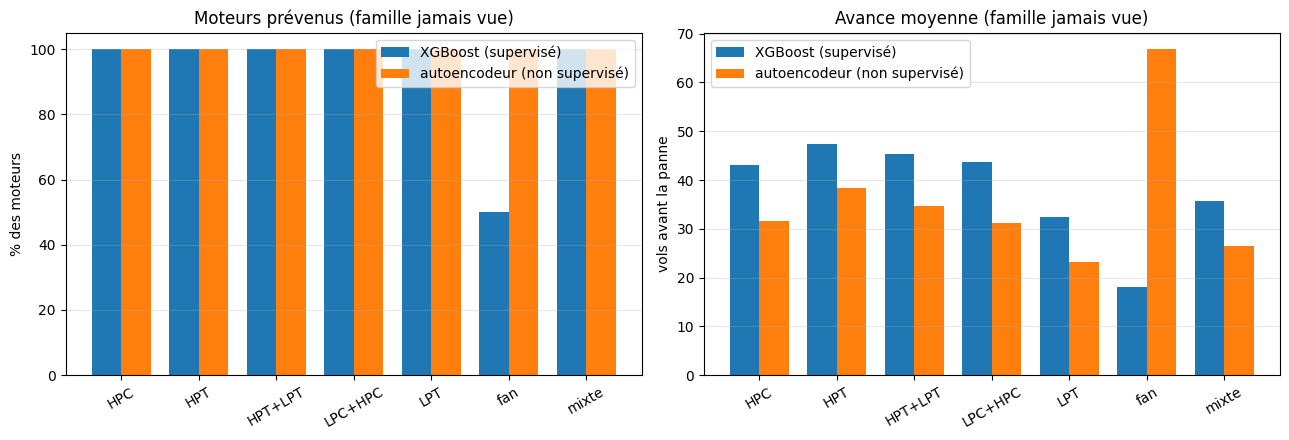

In [5]:
figure, axes = plt.subplots(1, 2, figsize=(13, 4.5))
positions = np.arange(len(panne_inconnue))
largeur = 0.38

for axe, (colonne_xgb, colonne_ae, titre, unite) in zip(axes, [
    ("xgb_detectes", "ae_detectes", "Moteurs prévenus (famille jamais vue)", "% des moteurs"),
    ("xgb_avance", "ae_avance", "Avance moyenne (famille jamais vue)", "vols avant la panne"),
]):
    xgb_valeurs = panne_inconnue[colonne_xgb]
    ae_valeurs = panne_inconnue[colonne_ae]
    if colonne_xgb == "xgb_detectes":
        xgb_valeurs = 100 * xgb_valeurs / panne_inconnue["moteurs"]
        ae_valeurs = 100 * ae_valeurs / panne_inconnue["moteurs"]
    axe.bar(positions - largeur / 2, xgb_valeurs.fillna(0), largeur, label="XGBoost (supervisé)")
    axe.bar(positions + largeur / 2, ae_valeurs.fillna(0), largeur, label="autoencodeur (non supervisé)")
    axe.set_xticks(positions, panne_inconnue.index, rotation=30)
    axe.set_title(titre)
    axe.set_ylabel(unite)
    axe.legend()
    axe.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(f"{DOSSIER}/results/figures/54_panne_inconnue.png", dpi=150)
plt.show()

In [6]:
from aeroguard.metier import bilan_flotte

FOCUS = "fan"
masque_focus = famille == FOCUS
infos_focus = infos_hors_test[masque_focus].assign(y=y_np[masque_focus])
d = details[FOCUS]

par_moteur_xgb = bilan_flotte(infos_focus.assign(alerte=(d["probas"] >= SEUIL_XGB).astype(int)),
                              col_moteur="moteur", k=K_XGB)
par_moteur_ae = bilan_flotte(infos_focus.assign(alerte=(d["erreurs"] > d["seuil_ae"]).astype(int)),
                             col_moteur="moteur", k=K_AE)
zoom_fan = par_moteur_xgb.merge(par_moteur_ae, on="moteur", suffixes=("_xgboost", "_autoencodeur"))
print("Avance = vols restants à la 1re alerte confirmée (NaN = moteur jamais prévenu)")
zoom_fan

Avance = vols restants à la 1re alerte confirmée (NaN = moteur jamais prévenu)


,moteur,avance_xgboost,fausses_alarmes_xgboost,avance_autoencodeur,fausses_alarmes_autoencodeur
0,DS04_1,26.0,0,65.0,17
1,DS04_2,NaN,0,56.0,12
2,DS04_3,11.0,0,78.0,17
3,DS04_4,NaN,0,53.0,11
4,DS04_5,NaN,0,83.0,12
5,DS04_6,17.0,0,66.0,12


In [7]:
panne_inconnue.to_csv(f"{DOSSIER}/results/v5_panne_inconnue.csv")
zoom_fan.to_csv(f"{DOSSIER}/results/v5_panne_inconnue_zoom_fan.csv", index=False)

mlflow.set_experiment("aeroguard-anomalies")
with mlflow.start_run(run_name="panne_inconnue") as run:
    mlflow.log_params({"protocole": "une famille retirée à la fois (vols sains et usés)",
                       "evaluation": "moteurs train + validation de la famille retirée",
                       "xgboost": f"seuil {SEUIL_XGB}, k {K_XGB}", "autoencodeur": f"p{PERCENTILE_AE}, k {K_AE}"})
    for nom, ligne in panne_inconnue.iterrows():
        cle = str(nom).replace("+", "_")
        mlflow.log_metrics({
            f"{cle}_xgb_detectes_pct": 100 * ligne["xgb_detectes"] / ligne["moteurs"],
            f"{cle}_ae_detectes_pct": 100 * ligne["ae_detectes"] / ligne["moteurs"],
        })
    mlflow.log_artifact(f"{DOSSIER}/results/figures/54_panne_inconnue.png")
    mlflow.log_artifact(f"{DOSSIER}/results/v5_panne_inconnue.csv")
    mlflow.set_tags({"lecon": "5.4", "tache": "anomalie", "jeu": "train+validation, famille retirée"})
print("✅ Run enregistré :", run.info.run_id[:8])

✅ Run enregistré : 80b010df


In [8]:
dossiers_artifacts = set()
for experience in mlflow.search_experiments():
    emplacement = experience.artifact_location.replace("file://", "")
    if emplacement.startswith("/content") and not emplacement.startswith("/content/drive"):
        dossiers_artifacts.add(os.path.dirname(emplacement))

shutil.copytree(DOSSIER_MLFLOW_LOCAL, DOSSIER_MLFLOW_DRIVE, dirs_exist_ok=True)
for dossier in dossiers_artifacts:
    if os.path.exists(dossier):
        shutil.copytree(dossier, f"{DOSSIER}/{os.path.basename(dossier)}", dirs_exist_ok=True)
print("✅ MLflow sauvegardé sur Drive")

✅ MLflow sauvegardé sur Drive
